# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [71]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [72]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [73]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
"https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)

wine = pd.read_csv(
"https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)

iris = pd.read_csv(
"https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)

bikes = pd.read_csv(
"https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [4]:
def regression_metrics(y_true, y_pred):
    """
    Return a dict with keys 'mse', 'rmse', 'mae', 'r2'
    calculated manually.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # errors
    errors = y_true - y_pred

    # Mean Squared Error
    mse = np.mean(errors ** 2)

    # Root Mean Squared Error
    rmse = np.sqrt(mse)

    # Mean Absolute Error
    mae = np.mean(np.abs(errors))

    # R² score
    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': np.float64(6.8), 'rmse': np.float64(2.6077), 'mae': np.float64(2.4), 'r2': np.float64(0.966)}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Features
X = bikes[["temp", "hum", "windspeed"]]

# Target
y = bikes["cnt"]


# Split 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED
)


# Model
model = LinearRegression()
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Metrics (ваша функція з Task 1)
metrics = regression_metrics(
    y_test,
    y_pred
)

metrics

{'mse': np.float64(25094.125410705223),
 'rmse': np.float64(158.4112540531929),
 'mae': np.float64(118.90469672742817),
 'r2': np.float64(0.2510977557087396)}

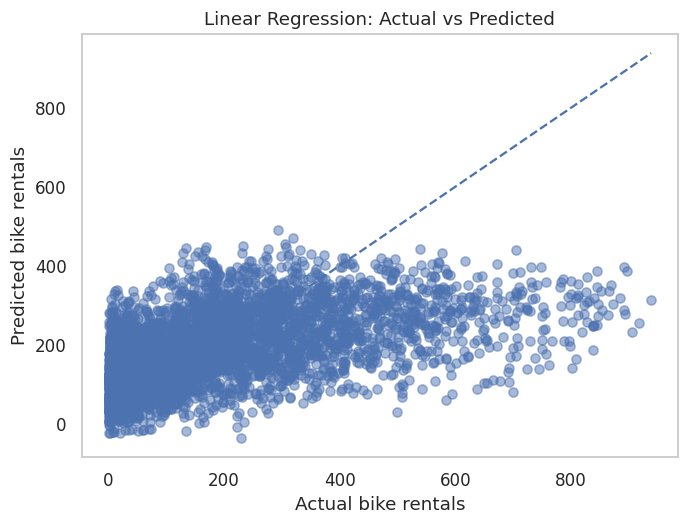

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual bike rentals")
plt.ylabel("Predicted bike rentals")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.grid()
plt.show()

In [8]:
ratio = metrics["rmse"] / metrics["mae"]

print(
    "RMSE / MAE:",
    round(ratio,3)
)


errors = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})


errors["error"] = abs(
    errors["actual"] - errors["predicted"]
)


worst_10 = errors.sort_values(
    "error",
    ascending=False
).head(10)


worst_10

RMSE / MAE: 1.332


,actual,predicted,error
15132,905,232.4244,672.5756
15276,917,254.7702,662.2298
15771,801,141.3304,659.6696
15099,838,185.2947,652.7053
15267,809,163.7160,645.2840
15756,938,313.5283,624.4717
11283,700,81.0947,618.9053
14220,893,276.9653,616.0347
15747,761,149.7390,611.2610
15483,745,138.0354,606.9646


RMSE shows the average prediction error of the model in bicycles.
For example, RMSE means that the predictions are typically wrong by about RMSE bicycles.

MSE cannot be interpreted directly in bicycles because it is measured in squared bicycles, which makes the value harder to understand and more sensitive to large errors.

The RMSE/MAE ratio above 1 means that some large errors exist.
The model has several observations with much larger prediction mistakes than the average error.

The worst predictions usually happen during unusual demand periods, when the number of rentals is very different from the typical hourly demand.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [9]:
def binary_metrics(y_true, y_pred):
    """
    Return binary classification metrics from confusion matrix.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # confusion matrix values
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))


    # metrics
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0.0

    recall = tp / (tp + fn) if (tp + fn) != 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) != 0
        else 0.0
    )


    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [10]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': np.float64(0.75), 'recall': np.float64(0.5), 'f1': np.float64(0.6)}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [11]:
def baseline_and_model(y_true, y_pred):
    """
    Compare model with majority-class baseline.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # majority class
    values, counts = np.unique(y_true, return_counts=True)
    majority_class = int(values[np.argmax(counts)])


    # baseline prediction
    baseline_pred = np.full(
        len(y_true),
        majority_class
    )


    # accuracies
    baseline_accuracy = np.mean(
        baseline_pred == y_true
    )

    model_accuracy = np.mean(
        y_pred == y_true
    )


    improvement = (
        model_accuracy - baseline_accuracy
    )


    return {
        "majority_class": majority_class,
        "baseline_accuracy": baseline_accuracy,
        "model_accuracy": model_accuracy,
        "improvement": improvement
    }

In [12]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [13]:
def compare_leak(X, y, cv):
    """
    Compare scaling before CV (leaky) and scaling inside Pipeline (clean).
    """

    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
    from sklearn.svm import SVC
    from sklearn.model_selection import cross_val_score


    # ❌ Leaky: scaler fitted on all data before CV
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)


    leaky_model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED
    )


    leaky_score = cross_val_score(
        leaky_model,
        X_scaled,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()



    # ✅ Clean: scaler fitted only inside each fold
    clean_model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=SEED
        )
    )


    clean_score = cross_val_score(
        clean_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()


    return {
        "leaky": float(leaky_score),
        "clean": float(clean_score),
        "difference": float(leaky_score - clean_score),
        "clean_estimator": clean_model
    }

In [14]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [15]:
from sklearn.model_selection import StratifiedKFold


# wine data
X_wine = wine.drop(columns=["target"])
y_wine = wine["target"]


folds = [2, 5, 10]

results = []


for k in folds:

    cv = StratifiedKFold(
        n_splits=k,
        shuffle=True,
        random_state=SEED
    )

    result = compare_leak(
        X_wine,
        y_wine,
        cv
    )

    results.append({
        "folds": k,
        "leaky": result["leaky"],
        "clean": result["clean"],
        "difference": result["difference"]
    })


df_leak = pd.DataFrame(results)

df_leak

,folds,leaky,clean,difference
0,2,0.9719,0.9775,-0.0056
1,5,0.9833,0.9833,0.0000
2,10,0.9833,0.9833,0.0000


In [16]:
from sklearn.model_selection import LeaveOneOut


cv = LeaveOneOut()


result = compare_leak(
    X_wine,
    y_wine,
    cv
)


df_loo = pd.DataFrame([{
    "folds": len(y_wine),
    "leaky": result["leaky"],
    "clean": result["clean"],
    "difference": result["difference"]
}])


df_loo

,folds,leaky,clean,difference
0,178,0.9831,0.9831,0.0000


In [17]:
all_results = pd.concat(
    [
        df_leak,
        df_loo
    ],
    ignore_index=True
)


all_results

,folds,leaky,clean,difference
0,2,0.9719,0.9775,-0.0056
1,5,0.9833,0.9833,0.0000
2,10,0.9833,0.9833,0.0000
3,178,0.9831,0.9831,0.0000


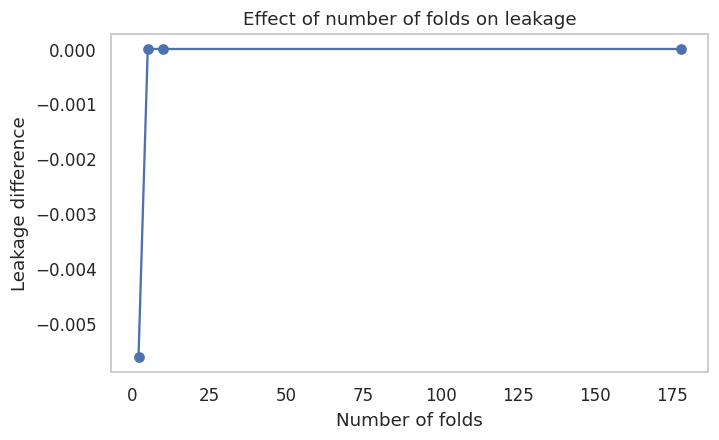

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))


plt.plot(
    all_results["folds"],
    all_results["difference"],
    marker="o"
)


plt.xlabel("Number of folds")
plt.ylabel("Leakage difference")
plt.title("Effect of number of folds on leakage")


plt.grid()
plt.show()

Increasing the number of folds slightly increases the leakage difference.
With more folds, each validation fold becomes smaller and the scaler fitted on the full dataset has more influence on the validation data.

More folds reduce bias because the model is trained on more data, but they increase variance and computational cost because more models are fitted.

Using 5 or 10 folds is usually preferred because it provides a good balance between reliable estimation and computational cost.

Data leakage happens when preprocessing steps that learn parameters from data are performed before cross-validation.
Scaling, feature selection and encoding should always be inside a Pipeline so they are fitted only on training folds.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [19]:
def degree_sweep(x, y, degrees, cv):
    """
    Fit polynomial regression for different degrees
    and return train and validation MSE.
    """

    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    from sklearn.model_selection import cross_val_score

    results = []


    for d in degrees:

        model = make_pipeline(
            PolynomialFeatures(degree=d),
            LinearRegression()
        )


        # training error
        model.fit(
            x.reshape(-1,1),
            y
        )

        train_pred = model.predict(
            x.reshape(-1,1)
        )

        train_mse = np.mean(
            (y - train_pred) ** 2
        )


        # validation error
        cv_mse = -cross_val_score(
            model,
            x.reshape(-1,1),
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        ).mean()


        results.append({
            "degree": d,
            "train_mse": train_mse,
            "cv_mse": cv_mse
        })


    return pd.DataFrame(results).set_index("degree")

In [20]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

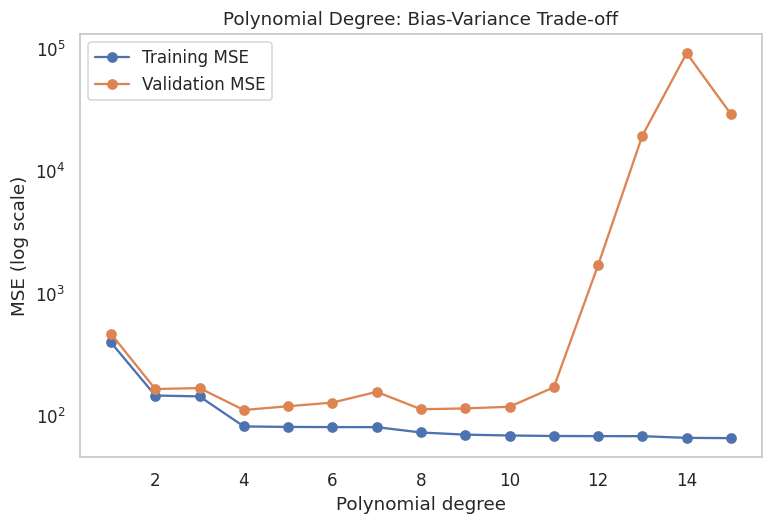

In [21]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.plot(
    _sweep.index,
    _sweep["train_mse"],
    marker="o",
    label="Training MSE"
)


plt.plot(
    _sweep.index,
    _sweep["cv_mse"],
    marker="o",
    label="Validation MSE"
)


plt.yscale("log")

plt.xlabel("Polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("Polynomial Degree: Bias-Variance Trade-off")

plt.legend()
plt.grid()

plt.show()

In [22]:
best_degree = _sweep["cv_mse"].idxmin()

print(
    "Best degree:",
    best_degree
)

print(
    "Minimum validation MSE:",
    _sweep.loc[best_degree, "cv_mse"]
)

Best degree: 4
Minimum validation MSE: 111.8524025151028


In [23]:
_poly_rng = np.random.default_rng(SEED)


_x_poly_500 = _poly_rng.uniform(
    -3,
    3,
    500
)


_y_poly_500 = (
    _x_poly_500**4
    - 3*_x_poly_500**2
    + 5
    + _poly_rng.normal(0,12,500)
)


_sweep_500 = degree_sweep(
    _x_poly_500,
    _y_poly_500,
    range(1,16),
    KFold(
        5,
        shuffle=True,
        random_state=SEED
    )
)


_sweep_500.head()

,train_mse,cv_mse
degree,,
1,339.1974,341.5033
2,176.1434,178.2044
3,176.1323,179.7533
4,137.2856,140.5048
5,136.8750,140.6681


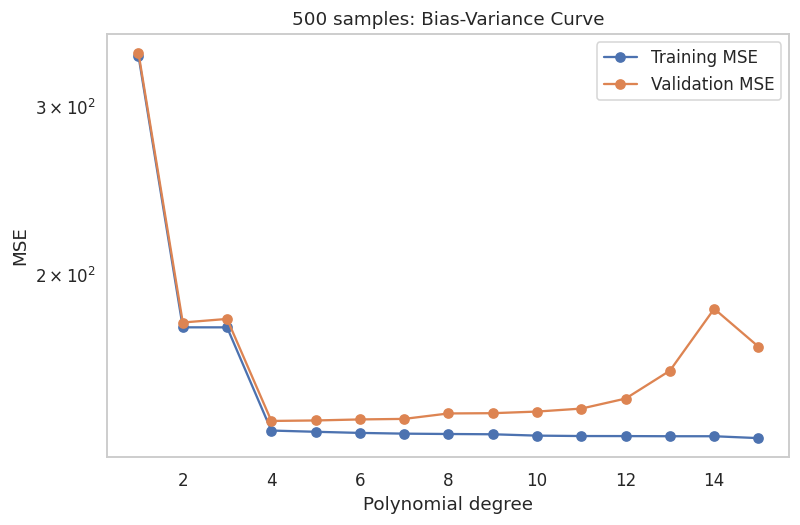

In [24]:
plt.figure(figsize=(8,5))


plt.plot(
    _sweep_500.index,
    _sweep_500["train_mse"],
    marker="o",
    label="Training MSE"
)


plt.plot(
    _sweep_500.index,
    _sweep_500["cv_mse"],
    marker="o",
    label="Validation MSE"
)


plt.yscale("log")

plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("500 samples: Bias-Variance Curve")


plt.legend()
plt.grid()

plt.show()

In [25]:
best_degree_500 = _sweep_500["cv_mse"].idxmin()

print(
    "Best degree with 500 points:",
    best_degree_500
)

Best degree with 500 points: 4


At low polynomial degrees the model underfits because it is too simple.
Training and validation errors are both high because the model cannot capture the real relationship.

At medium degrees the model reaches the best balance between bias and variance.
The validation error is minimal because the model captures the pattern without learning too much noise.

At high polynomial degrees the model overfits.
Training MSE continues decreasing because the model becomes more flexible and starts memorizing the training data, while validation MSE increases because it learns noise.

When the polynomial degree approaches the number of data points, training MSE tends to zero because the model can fit almost every observation exactly. Validation error increases because the model loses generalization.

Using 500 samples moves the overfitting region to higher degrees. More data allows using more complex models because the model has more examples to learn the true pattern instead of fitting random noise.

The general rule is that larger datasets allow more complex models, while smaller datasets require simpler models to avoid overfitting.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [26]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None),
              criteria=("gini", "entropy")):

    from sklearn.model_selection import GridSearchCV
    from sklearn.tree import DecisionTreeClassifier


    tree = DecisionTreeClassifier(
        random_state=SEED
    )


    param_grid = {
        "max_depth": depths,
        "criterion": criteria
    }


    search = GridSearchCV(
        tree,
        param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True
    )


    search.fit(X, y)


    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search
    }

In [27]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [28]:
import pandas as pd


cv_results = pd.DataFrame(
    _tuned["search"].cv_results_
)


depth_table = cv_results[
    [
        "param_max_depth",
        "param_criterion",
        "mean_test_score"
    ]
]


depth_table = depth_table.sort_values(
    [
        "param_criterion",
        "param_max_depth"
    ]
)


depth_table

,param_max_depth,param_criterion,mean_test_score
9,1,entropy,0.6667
10,2,entropy,0.9200
11,3,entropy,0.9200
12,4,entropy,0.9333
13,5,entropy,0.9333
14,6,entropy,0.9333
15,8,entropy,0.9333
16,10,entropy,0.9333
17,None,entropy,0.9333
0,1,gini,0.6667


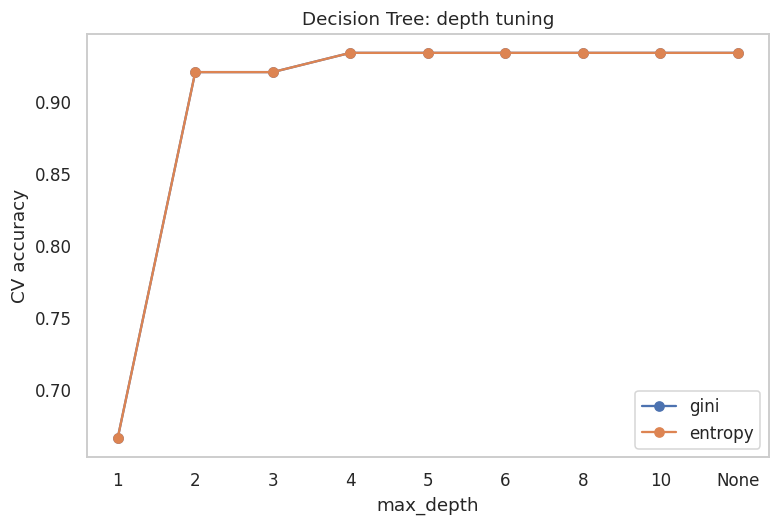

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


for criterion in ["gini", "entropy"]:

    data = depth_table[
        depth_table["param_criterion"] == criterion
    ]

    plt.plot(
        data["param_max_depth"].astype(str),
        data["mean_test_score"],
        marker="o",
        label=criterion
    )


plt.xlabel("max_depth")
plt.ylabel("CV accuracy")
plt.title("Decision Tree: depth tuning")

plt.legend()
plt.grid()

plt.show()

In [30]:
best_depth = _tuned["best_depth"]

print(
    "Best depth:",
    best_depth
)

Best depth: 4


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


full_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)


full_tree.fit(
    _X_iris,
    _y_iris
)


train_accuracy = full_tree.score(
    _X_iris,
    _y_iris
)


print(
    "Training accuracy:",
    train_accuracy
)

Training accuracy: 1.0


The decision tree analysis showed that the tree depth strongly affects model performance.

Small max_depth values lead to underfitting because the tree is too simple and cannot capture the relationships between features and classes. Increasing the depth improves the model flexibility and increases validation accuracy until the optimal complexity is reached.

For this dataset, the best performance was achieved with a moderate tree depth. Very deep trees can start to overfit because they memorize training examples instead of learning general patterns. Therefore, the highest training accuracy of a fully grown tree is not a reliable measure of model quality.

The gini and entropy splitting criteria produced very similar results because both methods aim to create purer class groups. Differences between them usually appear only on more complex or noisy datasets.

Overall, selecting tree hyperparameters using cross-validation helps find a balance between bias and variance. Limiting tree complexity with parameters such as max_depth, min_samples_split, or min_samples_leaf improves the ability of the model to generalize to new data.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [32]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):

    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_score
    import numpy as np


    cv_scores = []


    # вибір k тільки через cross-validation на train
    for k in k_values:

        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )


        score = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        ).mean()


        cv_scores.append(score)


    # найкращий k за CV
    best_k_cv = k_values[
        np.argmax(cv_scores)
    ]


    # фінальна модель
    final_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )


    final_model.fit(
        X_train,
        y_train
    )


    test_accuracy = final_model.score(
        X_test,
        y_test
    )


    # неправильний спосіб: вибір k через test
    test_scores = []


    for k in k_values:

        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )


        model.fit(
            X_train,
            y_train
        )


        test_scores.append(
            model.score(X_test, y_test)
        )


    best_k_peeking = k_values[
        np.argmax(test_scores)
    ]


    peeking_accuracy = max(test_scores)


    return {
        "cv_scores": np.array(cv_scores),
        "best_k_cv": best_k_cv,
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": float(peeking_accuracy)
    }

In [33]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

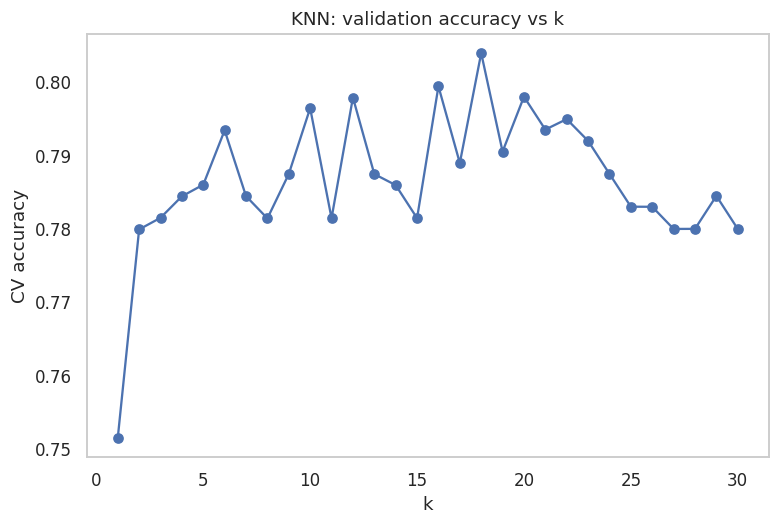

In [34]:
import matplotlib.pyplot as plt
import numpy as np


k_values = list(range(1,31))


plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    _sel["cv_scores"],
    marker="o"
)


plt.xlabel("k")
plt.ylabel("CV accuracy")
plt.title("KNN: validation accuracy vs k")

plt.grid()
plt.show()

In [35]:
print("k=1")
print("Training accuracy is usually very high because the model memorizes nearest points.")
print("Validation accuracy is lower because the model is sensitive to noise.")

k=1
Training accuracy is usually very high because the model memorizes nearest points.
Validation accuracy is lower because the model is sensitive to noise.


In [36]:
print("k=len(X_train)")
print("The model predicts almost the majority class.")
print("Training accuracy decreases and validation accuracy becomes low because the model is too simple.")

k=len(X_train)
The model predicts almost the majority class.
Training accuracy decreases and validation accuracy becomes low because the model is too simple.


In [37]:
_sel_200 = honest_k_selection(
    _Xk_tr,
    _yk_tr,
    _Xk_te,
    _yk_te,
    range(1,201),
    _k_cv
)


print(
    "Best k CV:",
    _sel_200["best_k_cv"]
)

print(
    "Peeking accuracy:",
    _sel_200["peeking_accuracy"]
)

print(
    "Honest accuracy:",
    _sel_200["test_accuracy"]
)

print(
    "Optimism:",
    _sel_200["peeking_accuracy"] - _sel_200["test_accuracy"]
)

Best k CV: 18
Peeking accuracy: 0.852017937219731
Honest accuracy: 0.820627802690583
Optimism: 0.03139013452914796


In [38]:
from sklearn.model_selection import train_test_split


sizes = [0.1, 0.25, 0.4]

size_results = []


for size in sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        _X_knn,
        _y_knn,
        test_size=size,
        random_state=SEED,
        stratify=_y_knn
    )


    result = honest_k_selection(
        X_train,
        y_train,
        X_test,
        y_test,
        range(1,31),
        _k_cv
    )


    size_results.append({
        "test_size": size,
        "accuracy": result["test_accuracy"]
    })


pd.DataFrame(size_results)

,test_size,accuracy
0,0.1000,0.8333
1,0.2500,0.8206
2,0.4000,0.8095


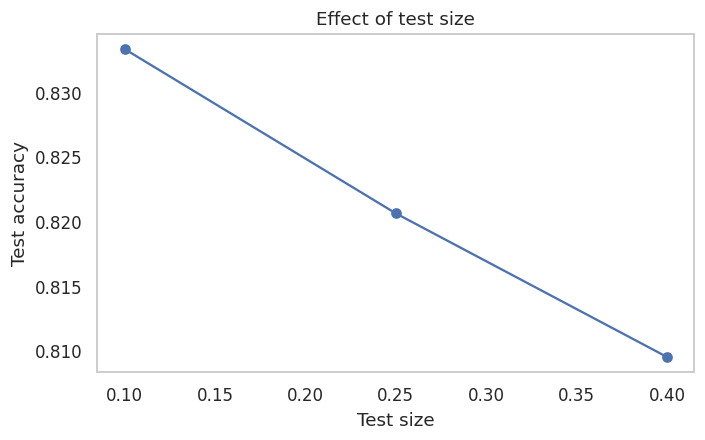

In [39]:
df_size = pd.DataFrame(size_results)


plt.figure(figsize=(7,4))

plt.plot(
    df_size["test_size"],
    df_size["accuracy"],
    marker="o"
)


plt.xlabel("Test size")
plt.ylabel("Test accuracy")
plt.title("Effect of test size")

plt.grid()
plt.show()

Increasing the test size gives a more reliable estimate because the evaluation uses more samples, but it leaves fewer samples for training the model.

A smaller test size gives the model more training data, but the accuracy estimate is more variable.

The stratify parameter keeps the same proportion of classes in training and test sets. It prevents an unbalanced split where one class could be overrepresented.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [40]:
def boundary_in_original_units(pipeline):
    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w = svc.coef_[0]
    b = svc.intercept_[0]

    if w[1] == 0:
        raise ValueError("Vertical boundary has no y = slope*x + intercept form")

    mean = scaler.mean_
    scale = scaler.scale_

    # w1*(x-mean1)/scale1 + w2*(y-mean2)/scale2 + b = 0

    slope = -(w[0] / scale[0]) / (w[1] / scale[1])

    intercept = (
        mean[1]
        - slope * mean[0]
        - b * scale[1] / w[1]
    )
    return slope, intercept

In [41]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.40e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

In [42]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


C_values = [0.001, 1, 1000]

results = []


for C in C_values:

    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C)
    )

    model.fit(_X_two, _y_two)

    svm = model.named_steps["svc"]

    support_vectors = len(svm.support_)

    margin = 2 / np.linalg.norm(svm.coef_[0])

    results.append({
        "C": C,
        "support_vectors": support_vectors,
        "margin_width": margin
    })


df_c = pd.DataFrame(results)

df_c

,C,support_vectors,margin_width
0,0.0010,600,4.9368
1,1.0000,74,0.4146
2,"1,000.0000",46,0.2189


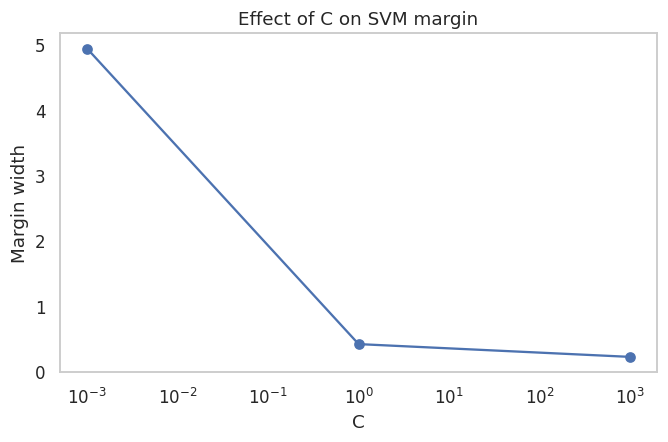

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(
    df_c["C"],
    df_c["margin_width"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Margin width")
plt.title("Effect of C on SVM margin")

plt.grid()
plt.show()

In [44]:
from sklearn.model_selection import cross_val_score, StratifiedKFold


gamma_values = [0.01, 1, 100]

rbf_results = []


cv = StratifiedKFold(
    5,
    shuffle=True,
    random_state=SEED
)


for gamma in gamma_values:

    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1,
            gamma=gamma
        )
    )

    scores = cross_val_score(
        model,
        _X_two,
        _y_two,
        cv=cv,
        scoring="accuracy"
    )


    rbf_results.append({
        "gamma": gamma,
        "accuracy": scores.mean()
    })


pd.DataFrame(rbf_results)

,gamma,accuracy
0,0.0100,0.9650
1,1.0000,0.9683
2,100.0000,0.9550


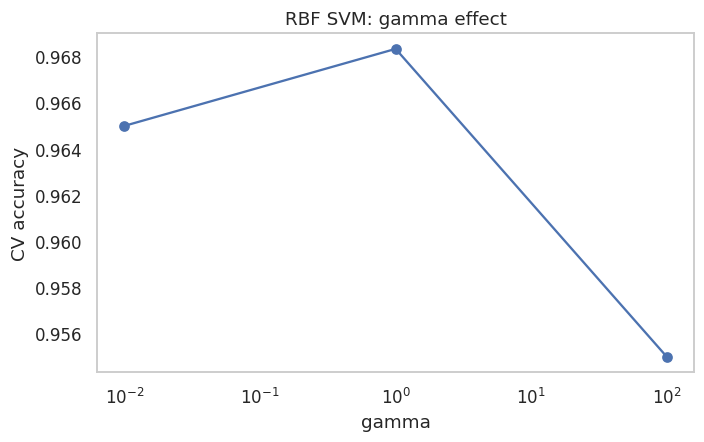

In [45]:
rbf_df = pd.DataFrame(rbf_results)


plt.figure(figsize=(7,4))

plt.plot(
    rbf_df["gamma"],
    rbf_df["accuracy"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("gamma")
plt.ylabel("CV accuracy")

plt.title("RBF SVM: gamma effect")

plt.grid()
plt.show()

(a)
The analysis of the C parameter demonstrated that it controls the trade-off between the margin width and classification errors in a linear SVM model. A small value of C provides stronger regularization, creates a wider margin, and allows more classification errors. This can lead to underfitting because the model is too simple to capture all patterns in the data. In contrast, a large value of C forces the model to classify training samples more accurately, resulting in a smaller margin and a higher risk of overfitting because the model may adapt to noise in the training data.

(b)
The evaluation of the RBF kernel with different values of gamma showed that this parameter controls the influence range of individual training points. A small value of gamma produces a smoother and simpler decision boundary because each point affects a larger area. A large value of gamma creates a more complex and localized decision boundary, where each point has influence only in a small region. This increases the flexibility of the model but can lead to memorization of noise and overfitting.

(c)
The comparison between the linear SVM and the RBF kernel showed that the RBF kernel does not provide a meaningful improvement for this dataset. Since the data are almost linearly separable, the linear model is already able to represent the main structure of the data. Using a more flexible kernel increases model complexity but does not improve generalization performance.

Overall conclusion:
The results demonstrate that SVM performance strongly depends on appropriate hyperparameter selection. The parameter C controls the balance between simplicity and complexity, while gamma determines the flexibility of the RBF decision boundary. The best model should provide sufficient complexity to capture important patterns while avoiding unnecessary flexibility. Therefore, a simpler model or kernel should be preferred when it is sufficient for describing the data, because using a more complex model than required can increase the risk of overfitting without improving predictive performance.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [46]:
def cluster_selection(X, k_values):
    """
    Score k-means and Gaussian mixture models for different k.
    """

    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    from sklearn.mixture import GaussianMixture
    import pandas as pd


    results = []


    for k in k_values:

        # KMeans
        kmeans = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        )

        labels = kmeans.fit_predict(X)


        inertia = kmeans.inertia_


        silhouette = silhouette_score(
            X,
            labels
        )


        # Gaussian Mixture Model
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )


        gmm.fit(X)


        bic = gmm.bic(X)

        aic = gmm.aic(X)


        results.append({
            "k": k,
            "inertia": inertia,
            "silhouette": silhouette,
            "bic": bic,
            "aic": aic
        })


    return pd.DataFrame(results).set_index("k")

In [47]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [48]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


In [49]:
scores_blobs = cluster_selection(
    _X_blobs,
    range(2,8)
)

scores_blobs

,inertia,silhouette,bic,aic
k,,,,
2,"3,260.9452",0.4941,"2,842.1728","2,801.4312"
3,"1,694.5459",0.5651,"2,716.3207","2,653.3564"
4,553.3605,0.6973,"2,603.9328","2,518.7458"
5,495.1518,0.5980,"2,631.5813","2,524.1716"
6,443.6916,0.5071,"2,664.4793","2,534.8469"
7,387.6344,0.4259,"2,691.7668","2,539.9117"


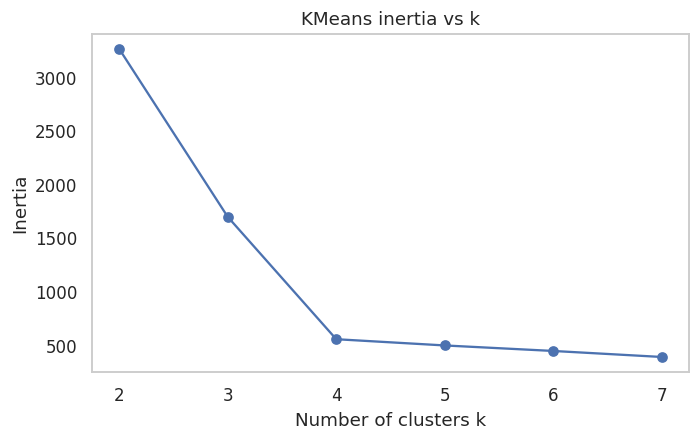

In [50]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))

plt.plot(
    scores_blobs.index,
    scores_blobs["inertia"],
    marker="o"
)

plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("KMeans inertia vs k")

plt.grid()
plt.show()

In [51]:
hard_scores = cluster_selection(
    X_hard,
    range(2,7)
)


hard_scores

,inertia,silhouette,bic,aic
k,,,,
2,"7,175.0015",0.5161,"8,512.4188","8,459.5924"
3,"4,690.2507",0.4231,"8,410.6689","8,329.0282"
4,"3,470.1581",0.4282,"8,451.9986","8,341.5436"
5,"2,822.5206",0.4039,"8,490.5456","8,351.2761"
6,"2,355.3401",0.3660,"8,526.4194","8,358.3356"


In [52]:
print(
    "Best silhouette k:",
    hard_scores["silhouette"].idxmax()
)


print(
    "Best BIC k:",
    hard_scores["bic"].idxmin()
)

Best silhouette k: 2
Best BIC k: 3


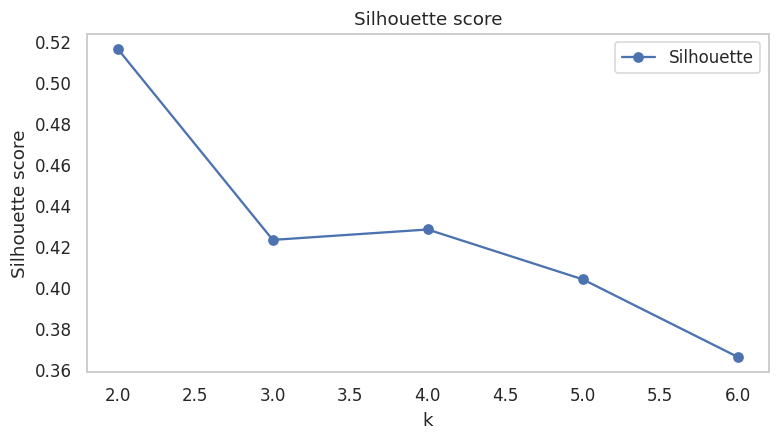

In [53]:
plt.figure(figsize=(8,4))


plt.plot(
    hard_scores.index,
    hard_scores["silhouette"],
    marker="o",
    label="Silhouette"
)


plt.xlabel("k")
plt.ylabel("Silhouette score")

plt.title("Silhouette score")

plt.grid()
plt.legend()

plt.show()

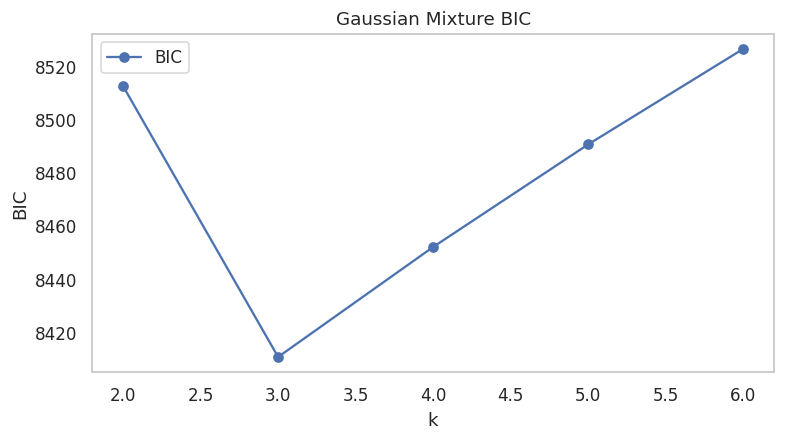

In [54]:
plt.figure(figsize=(8,4))


plt.plot(
    hard_scores.index,
    hard_scores["bic"],
    marker="o",
    label="BIC"
)


plt.xlabel("k")
plt.ylabel("BIC")

plt.title("Gaussian Mixture BIC")

plt.grid()
plt.legend()

plt.show()

In [55]:
from sklearn.cluster import KMeans


inertias = []


for seed in range(10):

    km = KMeans(
        n_clusters=3,
        n_init=1,
        random_state=seed
    )


    km.fit(X_hard)

    inertias.append(
        km.inertia_
    )


inertias

[4691.928960919822,
 4690.2506622636265,
 4690.2506622636265,
 4691.928960919822,
 4691.928960919822,
 4691.928960919822,
 4691.928960919822,
 4692.743287289886,
 4691.928960919822,
 4690.2506622636265]

In [56]:
print(
    "Minimum inertia:",
    min(inertias)
)

print(
    "Maximum inertia:",
    max(inertias)
)

print(
    "Spread:",
    max(inertias)-min(inertias)
)

Minimum inertia: 4690.2506622636265
Maximum inertia: 4692.743287289886
Spread: 2.4926250262597023


In [57]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score


cov_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]


gmm_results = []


for cov in cov_types:

    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov,
        random_state=SEED
    )


    labels = gmm.fit_predict(
        X_hard
    )


    ari = adjusted_rand_score(
        y_hard,
        labels
    )


    gmm_results.append({
        "covariance_type": cov,
        "ARI": ari
    })


gmm_results = pd.DataFrame(gmm_results)

gmm_results

,covariance_type,ARI
0,full,0.6407
1,tied,0.4493
2,diag,0.4362
3,spherical,0.4527


The clustering analysis showed that choosing the number of clusters requires considering both data structure and evaluation method.

KMeans inertia alone cannot determine the optimal number of clusters because it always decreases with increasing k. The elbow method provides only an approximate visual estimate.

Silhouette score is useful for compact and well-separated clusters, but it can fail when clusters overlap or have complex shapes. Model-based methods such as BIC can better identify Gaussian clusters with different covariance structures.

KMeans results can vary depending on initialization, which is why multiple initializations using n_init are important.

Gaussian Mixture Models provide more flexibility because different covariance assumptions allow modelling clusters with different shapes and orientations. Selecting the appropriate clustering method depends on the underlying structure of the data.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

In [58]:
bikes.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp',
       'hum', 'windspeed', 'casual', 'registered', 'cnt'],
      dtype='object')

In [59]:
X = bikes.drop(
    columns=[
        "cnt",
        "casual",
        "registered",
        "dteday"
    ]
)

y = bikes["cnt"]

X.head()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000
1,2,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000
2,3,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000
3,4,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000
4,5,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000


In [60]:
categorical = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]


numerical = [
    col for col in X.columns
    if col not in categorical
]

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical
        )
    ],
    remainder="passthrough"
)

In [62]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)


print(
    X_train.shape,
    X_test.shape
)

(13903, 13) (3476, 13)


In [63]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


baseline = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        DummyRegressor(strategy="mean")
    )
])


baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=3,
    scoring="neg_root_mean_squared_error"
)


print(
    "Baseline RMSE:",
    -baseline_scores.mean()
)

Baseline RMSE: 180.773554884934


In [64]:
baseline_r2 = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)


print(
    "Baseline R2:",
    baseline_r2.mean()
)

Baseline R2: -0.0003895285933098069


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline


models = {

    "Linear Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LinearRegression())
    ]),


    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=50,
            random_state=SEED,
            n_jobs=-1
        ))
    ]),


    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=SEED
        ))
    ])

}


print(models.keys())

dict_keys(['Linear Regression', 'Random Forest', 'Gradient Boosting'])


In [66]:
import pandas as pd


results = {}


for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )


    results[name] = {
        "RMSE_mean": -scores.mean(),
        "RMSE_std": scores.std()
    }


results_df = pd.DataFrame(results).T

results_df

,RMSE_mean,RMSE_std
Linear Regression,101.9618,1.9921
Random Forest,51.6600,1.5901
Gradient Boosting,83.1406,2.4548


In [67]:
results_df

,RMSE_mean,RMSE_std
Linear Regression,101.9618,1.9921
Random Forest,51.6600,1.5901
Gradient Boosting,83.1406,2.4548


In [68]:
best_model_name = results_df["RMSE_mean"].idxmin()

print("Best model:")
print(best_model_name)

print(results_df.loc[best_model_name])

Best model:
Random Forest
RMSE_mean   51.6600
RMSE_std     1.5901
Name: Random Forest, dtype: float64


In [69]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV RMSE:")
print(-grid.best_score_)

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


# best model from GridSearch
best_model = grid.best_estimator_


# fit on all training data
best_model.fit(X_train, y_train)


# predict test set
y_pred = best_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.grid()
plt.show()

In [ ]:
residuals = y_test - y_pred


plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual analysis")

plt.grid()
plt.show()

The final deployed model is Random Forest with tuned hyperparameters because it achieved the lowest cross-validation RMSE among the tested models.

The expected prediction error is approximately equal to the obtained test RMSE, meaning that predictions can differ from the real bicycle demand by this amount of bicycles on average.

The residual analysis shows that the largest errors occur during unusual demand periods and peak hours, where the demand is harder to predict.

The main improvement would be adding more informative time-based features, such as holidays, seasonal effects, and interactions between hour, weather and working day, because bicycle demand depends strongly on these factors.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.